In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [ ]:
df = pd.read_csv("traffic_data.csv")

In [ ]:
df.head()

,duration,total_fiat,total_biat,min_fiat,min_biat,max_fiat,max_biat,mean_fiat,mean_biat,flowPktsPerSecond,...,std_flowiat,min_active,mean_active,max_active,std_active,min_idle,mean_idle,max_idle,std_idle,traffic_type
0,119994459,119994459,119970125,0,0,1399330,1211310,2348.136257,513.267526,2373.792943,...,9107.759178,1753114,11300000.0,39438693,1.600000e+07,1014624,1139537.6,1208289,74997.38538,BROWSING
1,143704195,143704195,42106019,0,0,101572528,854818,6986.105737,636.898837,603.204381,...,345078.175900,143704195,144000000.0,143704195,0.000000e+00,101572528,102000000.0,101572528,0.00000,BROWSING
2,119994980,119994980,119966891,7,0,819852,819602,10201.919740,2341.411304,525.030297,...,17736.017270,-1,0.0,-1,0.000000e+00,-1,0.0,-1,0.00000,BROWSING
3,119292282,119292282,119260024,3,0,912990,866900,11947.148920,3354.712349,381.726288,...,24218.472200,-1,0.0,-1,0.000000e+00,-1,0.0,-1,0.00000,BROWSING
4,119772966,119772917,119772939,4,0,2894671,2923147,18210.873800,3644.280989,329.331412,...,31326.437350,2210292,8688035.0,15165778,9.160912e+06,1799762,2347216.5,2894671,774217.57870,BROWSING


In [ ]:
df = df.dropna()

print(df.shape)

(59706, 24)


In [ ]:
df.columns

Index(['duration', 'total_fiat', 'total_biat', 'min_fiat', 'min_biat',
       'max_fiat', 'max_biat', 'mean_fiat', 'mean_biat', 'flowPktsPerSecond',
       'flowBytesPerSecond', 'min_flowiat', 'max_flowiat', 'mean_flowiat',
       'std_flowiat', 'min_active', 'mean_active', 'max_active', 'std_active',
       'min_idle', 'mean_idle', 'max_idle', 'std_idle', 'traffic_type'],
      dtype='object')

In [ ]:
# Features (X)
X = df.drop("traffic_type", axis=1)

# Target (y)
y = df["traffic_type"]

print(X.shape)
print(y.shape)

(59706, 23)
(59706,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (47764, 23)
Testing Data: (11942, 23)


In [ ]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [ ]:
# Make predictions
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9108189582984425
Precision: 0.9149505299040842
Recall: 0.9108189582984425
F1-Score: 0.9107594818624359

Classification Report:
               precision    recall  f1-score   support

     BROWSING       0.93      0.95      0.94      2022
         CHAT       0.83      0.83      0.83       476
           FT       0.94      0.77      0.85       832
         MAIL       0.93      0.75      0.83       259
          P2P       0.97      0.97      0.97       829
    STREAMING       0.90      0.80      0.85       215
         VOIP       0.98      0.97      0.98      1294
 VPN-BROWSING       0.92      0.92      0.92      1984
     VPN-CHAT       0.84      0.76      0.80       576
       VPN-FT       0.86      0.84      0.85       917
     VPN-MAIL       0.89      0.97      0.93       519
      VPN-P2P       0.72      0.98      0.83       683
VPN-STREAMING       0.97      0.97      0.97       236
     VPN-VOIP       0.97      0.95      0.96      1100

     accuracy                     

In [ ]:
predictions = model.predict(X_test)

print(predictions[:10])

['VPN-BROWSING' 'VPN-BROWSING' 'VPN-MAIL' 'FT' 'P2P' 'P2P' 'VPN-P2P'
 'VPN-BROWSING' 'VPN-FT' 'VOIP']


In [ ]:
accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.9108189582984425


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

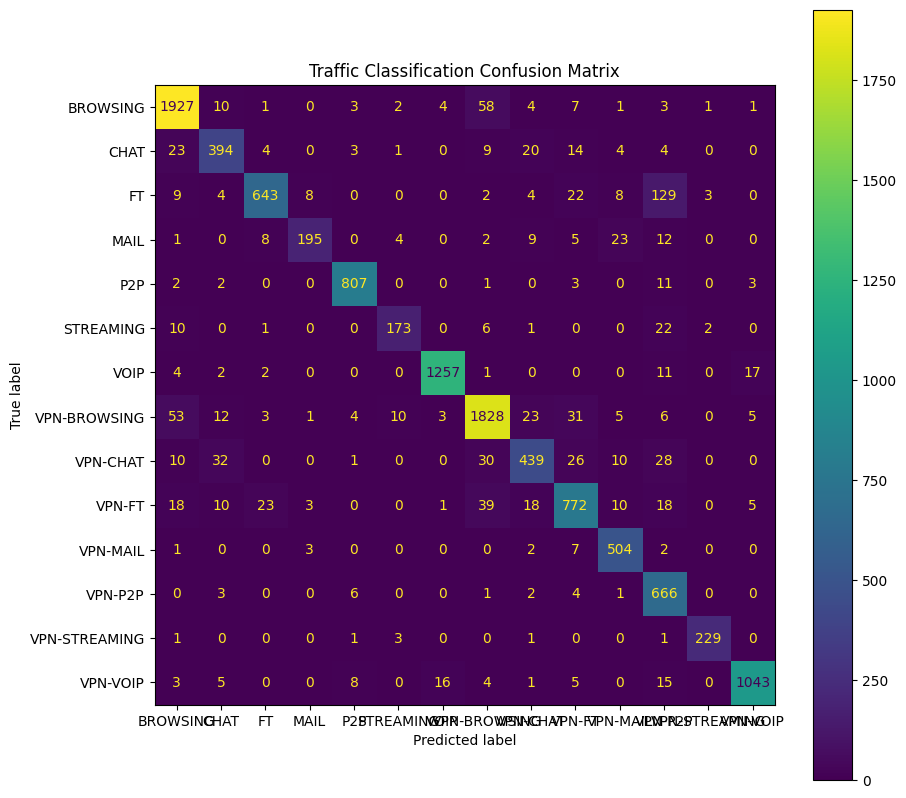

In [ ]:
cm = confusion_matrix(y_test, predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

fig, ax = plt.subplots(figsize=(10,10))

disp.plot(ax=ax)

plt.title("Traffic Classification Confusion Matrix")

plt.show()

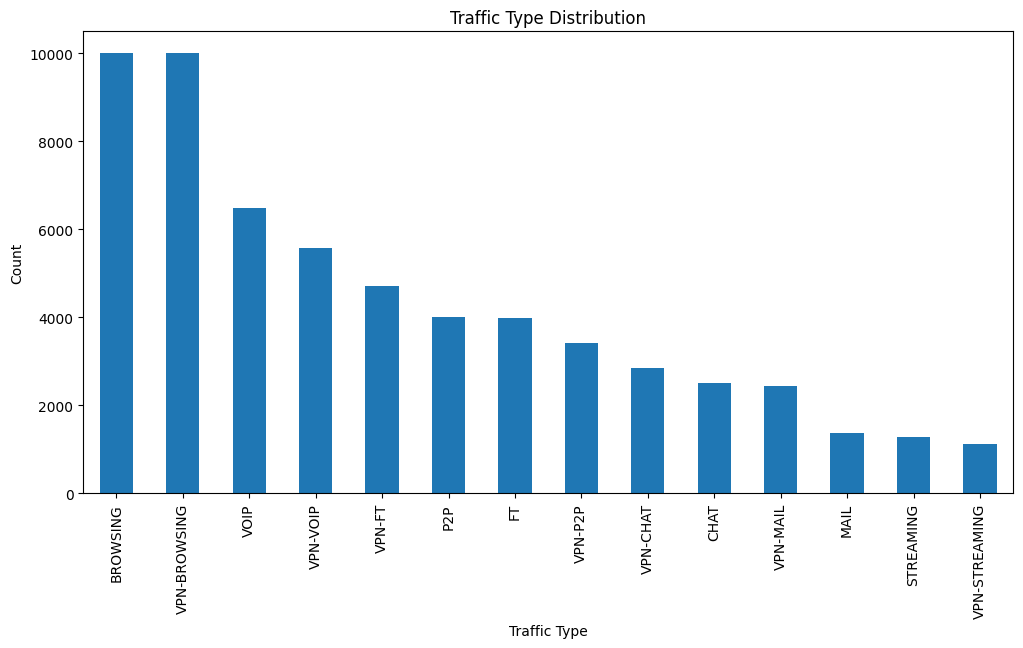

In [ ]:
traffic_counts = df['traffic_type'].value_counts()

traffic_counts.plot(kind='bar', figsize=(12,6))

plt.title("Traffic Type Distribution")
plt.xlabel("Traffic Type")
plt.ylabel("Count")

plt.show()

In [ ]:
def optimize_bandwidth(traffic_type):

    high_priority = ['VOIP', 'VPN-VOIP']
    medium_priority = [
        'STREAMING',
        'VPN-STREAMING',
        'BROWSING',
        'VPN-BROWSING'
    ]

    if traffic_type in high_priority:
        return "High Priority → Allocate Maximum Bandwidth"

    elif traffic_type in medium_priority:
        return "Medium Priority → Moderate Bandwidth Allocation"

    else:
        return "Low Priority → Restrict During Congestion"

In [ ]:
sample_traffic = predictions[:10]

for traffic in sample_traffic:
    decision = optimize_bandwidth(traffic)

    print("Traffic Type:", traffic)
    print("Optimization Decision:", decision)
    print("---------------------------")

Traffic Type: VPN-BROWSING
Optimization Decision: Medium Priority → Moderate Bandwidth Allocation
---------------------------
Traffic Type: VPN-BROWSING
Optimization Decision: Medium Priority → Moderate Bandwidth Allocation
---------------------------
Traffic Type: VPN-MAIL
Optimization Decision: Low Priority → Restrict During Congestion
---------------------------
Traffic Type: FT
Optimization Decision: Low Priority → Restrict During Congestion
---------------------------
Traffic Type: P2P
Optimization Decision: Low Priority → Restrict During Congestion
---------------------------
Traffic Type: P2P
Optimization Decision: Low Priority → Restrict During Congestion
---------------------------
Traffic Type: VPN-P2P
Optimization Decision: Low Priority → Restrict During Congestion
---------------------------
Traffic Type: VPN-BROWSING
Optimization Decision: Medium Priority → Moderate Bandwidth Allocation
---------------------------
Traffic Type: VPN-FT
Optimization Decision: Low Priority → 

In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 111.2 MB/s eta 0:00:00


In [ ]:
import joblib

joblib.dump(model, 'traffic_model.pkl')

print("Model saved successfully.")

Model saved successfully.


In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

# Load trained model
model = joblib.load('traffic_model.pkl')

# Page title
st.title("IoT Network Traffic Monitoring and Bandwidth Optimization System")

st.write("Machine Learning-Based Traffic Classification Dashboard")

# Upload dataset
uploaded_file = st.file_uploader("Upload Traffic Dataset", type=["csv"])

if uploaded_file is not None:

    df = pd.read_csv(uploaded_file)

    st.subheader("Dataset Preview")
    st.write(df.head())

    # Prediction
    if 'traffic_type' in df.columns:
        X = df.drop('traffic_type', axis=1)
    else:
        X = df

    predictions = model.predict(X)

    st.subheader("Traffic Predictions")
    st.write(predictions)

    # Optimization logic
    st.subheader("Bandwidth Optimization Decisions")

    for traffic in predictions[:10]:

        if traffic in ['VOIP', 'VPN-VOIP']:
            decision = "High Priority → Allocate Maximum Bandwidth"

        elif traffic in ['STREAMING', 'VPN-STREAMING', 'BROWSING', 'VPN-BROWSING']:
            decision = "Medium Priority → Moderate Bandwidth Allocation"

        else:
            decision = "Low Priority → Restrict During Congestion"

        st.write(f"{traffic} : {decision}")

Writing app.py


In [ ]:
!streamlit run app.py & npx localtunnel --port 8501

/bin/bash: line 1: streamlit: command not found
⠙⠹⠸⠼⠴⠦⠧⠇⠏your url is: https://witty-buses-argue.loca.lt
^C
